## Imports

In [ ]:
%pip install numpy matplotlib opencv-python 
#%pip install pandas seaborn sklearn scipy


Note: you may need to restart the kernel to use updated packages.


In [5]:
import os 
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 21/10/24
## Hafta 5
<hr>

### AA


##### A

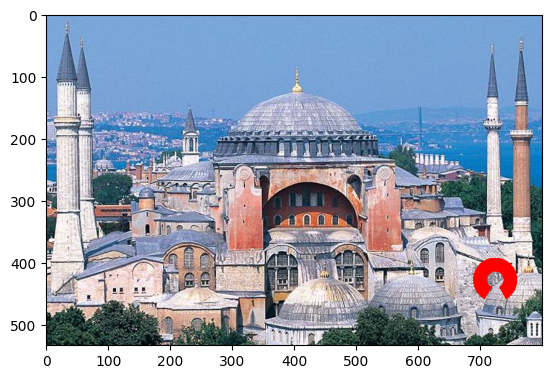

In [3]:
# Vize +10 puan

kucukResim = cv2.imread('DATA/11_opencv-logo-2.png')
buyukResim = cv2.imread('DATA/1_ayasofya.jpg')
kucukResim = cv2.cvtColor(kucukResim,cv2.COLOR_BGR2RGB)
buyukResim = cv2.cvtColor(buyukResim,cv2.COLOR_BGR2RGB)

kucukResim[:,:,1]= 0 
kucukResim[:,:,2]= 0

kYukseklik,kGenislik,kKanal = kucukResim.shape
bYukseklik,bGenislik,bKanal = buyukResim.shape

roi_alan = buyukResim[bYukseklik-kYukseklik:, bGenislik-kGenislik:].copy()
kucukResimGray = cv2.cvtColor(kucukResim,cv2.COLOR_RGB2GRAY)

ret, maske = cv2.threshold(kucukResimGray, 10, 255, cv2.THRESH_BINARY)
maske_tersi = cv2.bitwise_not(maske)

roi_alan_bg = cv2.bitwise_and(roi_alan, roi_alan, mask = maske_tersi)
roi_alan_fg = cv2.bitwise_and(kucukResim, kucukResim, mask = maske)

birlesmisParca = cv2.add(roi_alan_bg, roi_alan_fg)

buyukResim[bYukseklik-kYukseklik:, bGenislik-kGenislik:] = birlesmisParca
plt.imshow(buyukResim)

In [13]:
# Örnek 3.16 - Morfolojik Operatörler

orijinalResim = cv2.imread('DATA/12_normal_gray.jpg')
noised = cv2.imread('DATA/13_noised.jpg')
backGroundNoise = cv2.imread('DATA/14_backGround_noise.jpg')
foreGroundNoise = cv2.imread('DATA/15_foreGround_noise.jpg')

orijinalResim = cv2.cvtColor(orijinalResim,cv2.COLOR_BGR2RGB)
noised = cv2.cvtColor(noised,cv2.COLOR_BGR2RGB)
backGroundNoise = cv2.cvtColor(backGroundNoise,cv2.COLOR_BGR2RGB)
foreGroundNoise = cv2.cvtColor(foreGroundNoise,cv2.COLOR_BGR2RGB)


kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(17,17))

erosionSonuc1 = cv2.erode(orijinalResim,kernel,3)
dilationSonuc1 = cv2.dilate(orijinalResim,kernel,3)

erosionSonuc2 = cv2.erode(noised,kernel,2)
dilationSonuc2 = cv2.dilate(noised,kernel,2)

erosionSonuc3 = cv2.erode(backGroundNoise,kernel,1)
dilationSonuc3 = cv2.dilate(foreGroundNoise,kernel,1)

openingSonuc = cv2.morphologyEx(backGroundNoise,cv2.MORPH_OPEN,kernel)
closingSonuc = cv2.morphologyEx(foreGroundNoise,cv2.MORPH_CLOSE,kernel)

gradientSonuc = cv2.morphologyEx(orijinalResim,cv2.MORPH_GRADIENT,kernel)
topHatSonuc = cv2.morphologyEx(backGroundNoise,cv2.MORPH_TOPHAT,kernel)
blackHatSonuc = cv2.morphologyEx(foreGroundNoise,cv2.MORPH_BLACKHAT,kernel)

Text(15, 50, 'Black Hat')

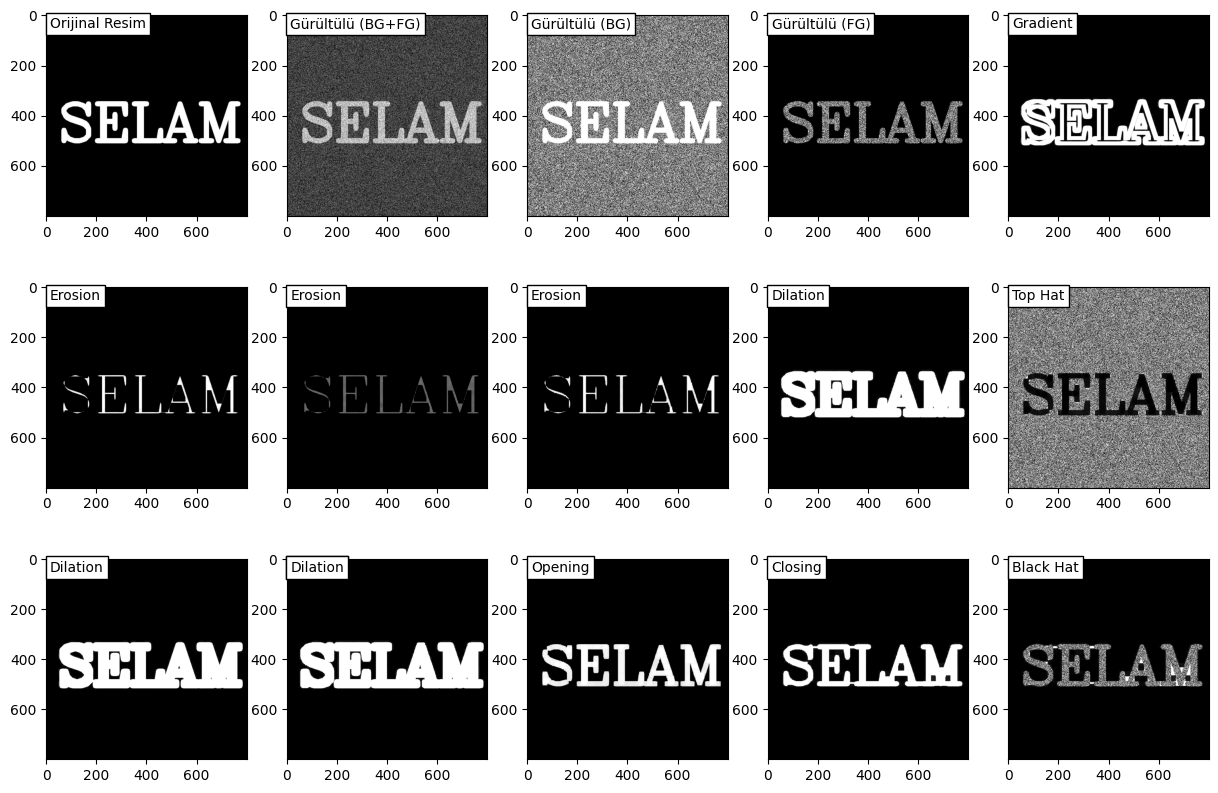

In [14]:
f, eksen = plt.subplots(3,5,figsize=(15,10))
eksen[0,0].imshow(orijinalResim, cmap="gray")
eksen[0,0].text(15, 50, 'Orijinal Resim', bbox={'facecolor': 'white', 'pad': 3})

eksen[0,1].imshow(noised, cmap="gray")
eksen[0,1].text(15, 50, 'Gürültülü (BG+FG)', bbox={'facecolor': 'white', 'pad': 3})

eksen[0,2].imshow(backGroundNoise, cmap="gray")
eksen[0,2].text(15, 50, 'Gürültülü (BG)', bbox={'facecolor': 'white', 'pad': 3})

eksen[0,3].imshow(foreGroundNoise, cmap="gray")
eksen[0,3].text(15, 50, 'Gürültülü (FG)', bbox={'facecolor': 'white', 'pad': 3})

eksen[0,4].imshow(gradientSonuc, cmap="gray")
eksen[0,4].text(15, 50, 'Gradient', bbox={'facecolor': 'white', 'pad': 3})

eksen[1,0].imshow(erosionSonuc1, cmap="gray")
eksen[1,0].text(15, 50, 'Erosion', bbox={'facecolor': 'white', 'pad': 3})

eksen[1,1].imshow(erosionSonuc2, cmap="gray")
eksen[1,1].text(15, 50, 'Erosion', bbox={'facecolor': 'white', 'pad': 3})

eksen[1,2].imshow(erosionSonuc3, cmap="gray")
eksen[1,2].text(15, 50, 'Erosion', bbox={'facecolor': 'white', 'pad': 3})

eksen[1,3].imshow(dilationSonuc3, cmap="gray")
eksen[1,3].text(15, 50, 'Dilation', bbox={'facecolor': 'white', 'pad': 3})

eksen[1,4].imshow(topHatSonuc, cmap="gray")
eksen[1,4].text(15, 50, 'Top Hat', bbox={'facecolor': 'white', 'pad': 3})

eksen[2,0].imshow(dilationSonuc1, cmap="gray")
eksen[2,0].text(15, 50, 'Dilation', bbox={'facecolor': 'white', 'pad': 3})

eksen[2,1].imshow(dilationSonuc2, cmap="gray")
eksen[2,1].text(15, 50, 'Dilation', bbox={'facecolor': 'white', 'pad': 3})

eksen[2,1].imshow(dilationSonuc3, cmap="gray")
eksen[2,1].text(15, 50, 'Dilation', bbox={'facecolor': 'white', 'pad': 3})

eksen[2,2].imshow(openingSonuc, cmap="gray")
eksen[2,2].text(15, 50, 'Opening', bbox={'facecolor': 'white', 'pad': 3})

eksen[2,3].imshow(closingSonuc, cmap="gray")
eksen[2,3].text(15, 50, 'Closing', bbox={'facecolor': 'white', 'pad': 3})

eksen[2,4].imshow(blackHatSonuc, cmap="gray")
eksen[2,4].text(15, 50, 'Black Hat', bbox={'facecolor': 'white', 'pad': 3})